# Notebook Python - Projet Machine Learning 

*Lucas Rosas, Jeanne Marque, Clélia Desjean, Laura Souverin*

---

In [5]:
#import des bibliothèques utilisées dans le projet

import numpy as np
import pandas as pd
import matplotlib as mlt
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import jinja2 as j2
import math

## 1-Import et modification des données 

### 1.1- Import des données et vérifications du contenu

In [6]:
#Importer les données 
path=""
health=pd.read_csv(path+"healthcare_synthetic_data.csv", sep=",", header=0)

#On vérifie le contenu
health.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


In [8]:
data_quality = pd.DataFrame({
    "colonne": health.columns,
    "n_unique": health.nunique().values,
    "n_missing": health.isna().sum().values,
    "missing_ratio": (health.isna().sum() / len(health)).values,
    "dtype": health.dtypes.astype(str).values
})
    # création visuel coloré
affichage_colore = (
    data_quality.style
    .background_gradient(subset=['n_missing', 'missing_ratio'], cmap='Reds')
    .bar(subset=['n_unique'], color='#5fba7d')
    .format({'missing_ratio': '{:.2%}'})
    .map(lambda x: 'font-weight: bold', subset=['colonne'])
)
display(affichage_colore)

,colonne,n_unique,n_missing,missing_ratio,dtype
0,Patient_ID,15000,0,0.00%,str
1,Age,61,0,0.00%,int64
2,Gender,2,0,0.00%,int64
3,Height_cm,516,0,0.00%,float64
4,Weight_kg,817,0,0.00%,float64
5,BMI,274,0,0.00%,float64
6,Systolic_BP,82,0,0.00%,int64
7,Diastolic_BP,61,0,0.00%,int64
8,Cholesterol_Total,161,0,0.00%,int64
9,Cholesterol_LDL,132,0,0.00%,int64


### 1.2- Modification des données 

Afin d'utiliser les méthodes de machine learning, certaines modifications doivent être apportées aux données.

**a) Modification des types**

Nous transformons les variables qualitatives en type *Categorical* pour préparer l'encodage binaire. Cela permet au modèle de traiter chaque catégorie séparément, sans établir d'ordre mathématique entre elles.


**NOTE : faut il transformer stress_level... ?**


In [9]:
health['Patient_ID'] = pd.Categorical(health['Patient_ID'])
health['Gender'] = pd.Categorical(health['Gender'])
health['Smoking_Status'] = pd.Categorical(health['Smoking_Status'])
health['Alcohol_Consumption'] = pd.Categorical(health['Alcohol_Consumption'])
health['Physical_Activity_Level'] = pd.Categorical(health['Physical_Activity_Level'])
health['Family_History'] = pd.Categorical(health['Family_History'])
health['Stress_Level'] = pd.Categorical(health['Stress_Level'])
health['Sleep_Hours'] = pd.Categorical(health['Sleep_Hours'])
health['Heart_Disease_Risk'] = pd.Categorical(health['Heart_Disease_Risk'])

health.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000



**b) Transformation en Gaussienne**

On définit une fonction pour observer la distribution de nos variables quantitatives 

In [10]:
def plot_quantitative(df):
    # Sélectionner les colonnes numériques du DataFrame
    vars_num = df.select_dtypes(include=['number']).columns
    n_vars = len(vars_num)
    
    # si toutes nos variables sont qualitatives, on affiche un message et on quitte la fonction
    if n_vars == 0:
        print("Aucune variable numérique trouvée.")
        return

    # Calculer le nombre de lignes nécessaires pour 3 colonnes dans la grille 
    ncols = 3
    nrows = math.ceil(n_vars / ncols)

    # Créer la figure et les axes
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()  # Aplatir pour itérer facilement

    for i, col in enumerate(vars_num):
        # Création de l'histogramme + densité (kde)
        sns.histplot(df[col], kde=True, stat="density", 
                     color="grey", edgecolor="black",bins=30, 
                     line_kws={"color": "blue"}, ax=axes[i])
        
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Density")
        axes[i].grid(True, alpha=0.3)

    # Supprimer les graphiques vides si n_vars n'est pas un multiple de 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

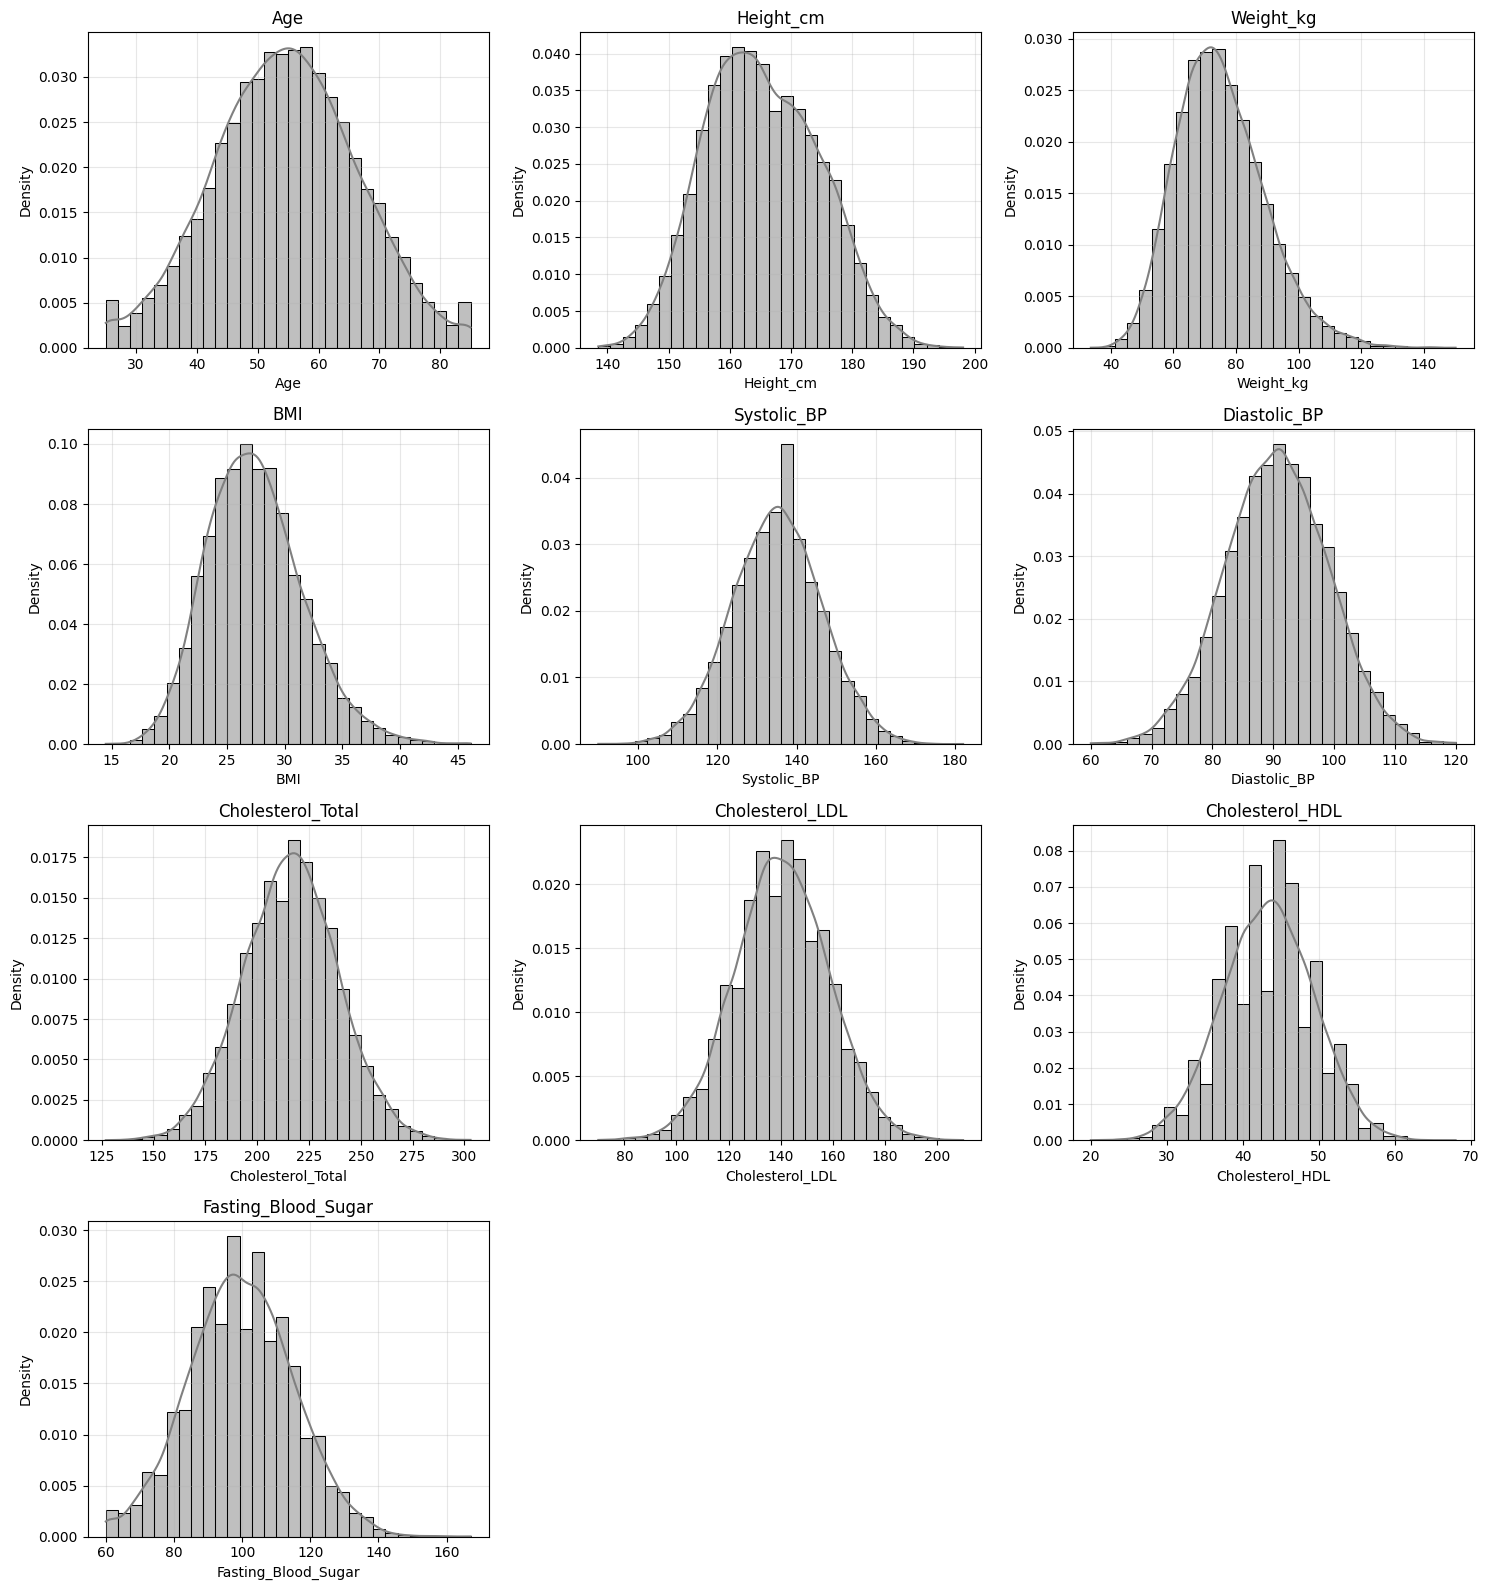

In [11]:
#on l'utilise sur notre dataset original 
plot_quantitative(health)

Nous pouvons observer que certaines variables, telles que l'âge ou le taux de cholestérol, sont relativement gaussiennes. Certaines sont asymétriques ou présentent de nombreux "trous". On transforme celles-ci en variables gaussiennes. Ceci est nécessaire à certaines méthodes telles que la régression linéaire. Cela permet aussi d'améliorer les performances et la stabilité de certains modèles, car la structure gaussienne est prévisible et régulière.

On utilise deux types de transformations : 
* *transformation logarithmique*: On applique cette transformation aux donnnées  (avec une trainée vars la droite)
* *transformation quantile*: On l'applique aux données avec des "pics" 

**NOTE / est ce que ça nous fait perdre des infos ?**

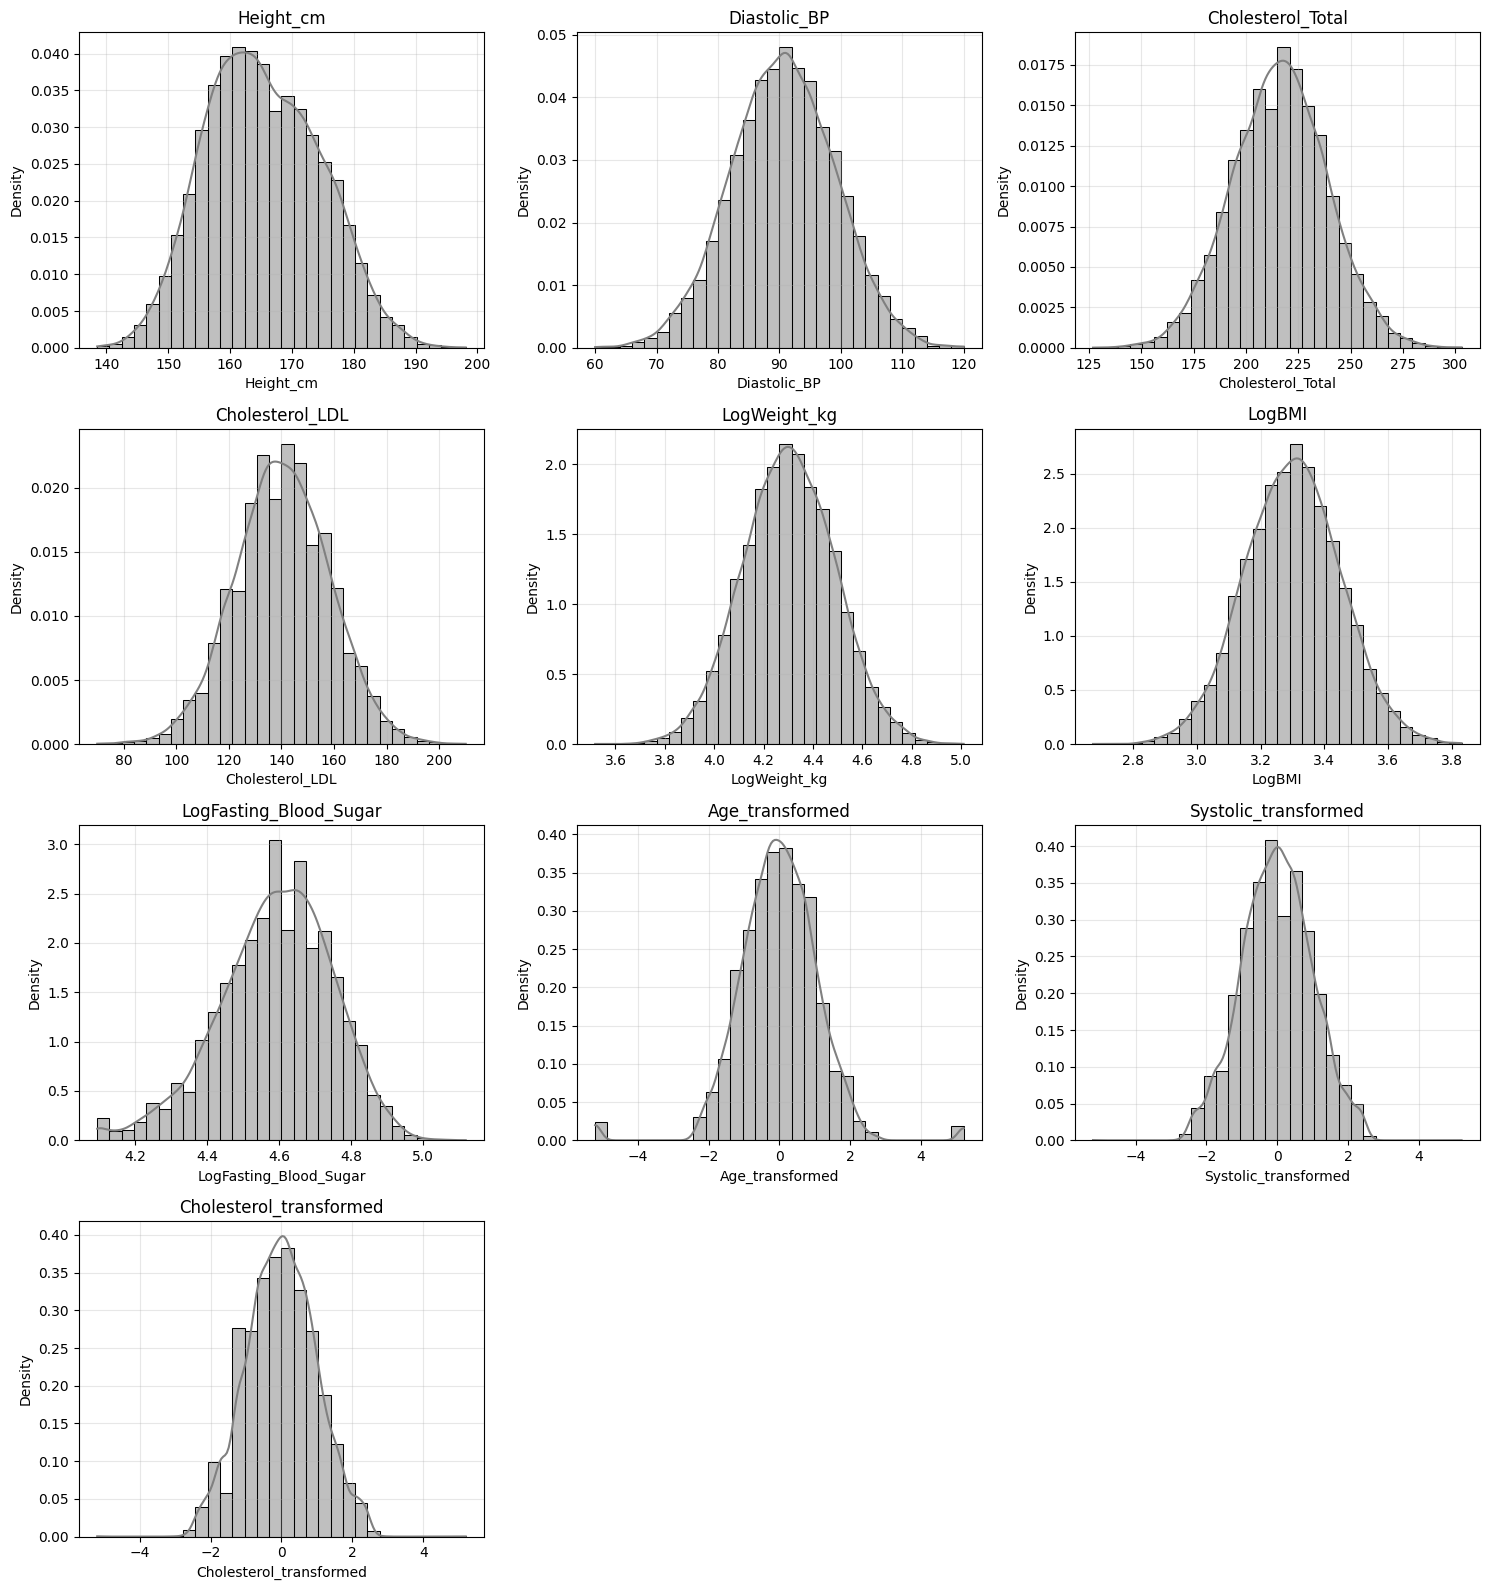

In [12]:
# on applique une transformation LOG sur les variables très asymétriques 
log_transformations = {
    "Weight_kg": "LogWeight_kg",
    "BMI": "LogBMI",
    "Fasting_Blood_Sugar": "LogFasting_Blood_Sugar"
}

#on applique une transformation QUANTILE sur les variables avec des outliers
# cette transformation tri les données et associe à chaque valeur un quantile de la distribution normale
qt_transformations = {
    "Age": "Age_transformed",
    "Systolic_BP": "Systolic_transformed",
    "Cholesterol_HDL": "Cholesterol_transformed"
}

# cette boucle nous permet de pouvoir relancer la cellule plusieurs fois sans erreur. Si la source n'existe plus, on ne fait rien
for old_col, new_col in log_transformations.items():
    if old_col in health.columns:
        health[new_col] = np.log(health[old_col])
        health = health.drop(columns=[old_col]) # On supprime l'originale tout de suite


from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)
#pareil pour la transformation quantile
for old_col, new_col in qt_transformations.items():
    if old_col in health.columns:
        health[new_col] = qt.fit_transform(health[[old_col]])
        health = health.drop(columns=[old_col])

#Affichage
plot_quantitative(health)

Il y a encore des défauts, on observe des "pics" ou des "trous" et des valeurs aberrantes. Cependant, ceci est lié à l'arrondi des données de santé, l'affichage... Les données sont assez gaussiennes pour notre utilisation. 

**c) Transformation des données pour l'apprentissage**

On commence par séparer les variables explicatives de la variable à expliquer. De plus, on utilise la fonction `pd.get_dummies` afin d'effectuer le *one hot encoding* de nos variables qualitatives. Elles se transforment ainsi en variables binaires indiquant si elles appartiennent, ou non, à chaque catégorie. 

In [14]:
#on définit la cible : le Heart_Disease_Risk, celle ci est binaire et indique si le patient est à risque de maladie cardiaque ou non
health_target = health['Heart_Disease_Risk']

health_features = health.drop(['Heart_Disease_Risk', 'Patient_ID'], axis=1)# Patient_ID est une variable catégorielle qui n'apporte pas d'information pour la prédiction

health_features = pd.get_dummies(health_features, columns=['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption','Stress_Level','Sleep_Hours'], drop_first=True)

**NOTE: tjr meme question est ce que les stress level etc doivent être en dummies**

Afin de sélectionner le meilleur modèle et de detecter l'over-fitting, nous devons créer un dataset de test. Nous séparons nos données en deux dataset.

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(health_features, health_target, test_size=0.2, train_size=0.8) # on renomme en X/y pour la lisibilité
print("la dimension de X_train est : ", np.shape(X_train))
print("la dimension de X_test est : ", np.shape(X_test))
print("la dimension de Y_train est : ", np.shape(Y_train))
print("la dimension de Y_test est : ", np.shape(Y_test))


la dimension de X_train est :  (12000, 31)
la dimension de X_test est :  (3000, 31)
la dimension de Y_train est :  (12000,)
la dimension de Y_test est :  (3000,)


On normalise les variables. Cela permet de comparer des valeurs avec differentes échelles et éviter qu'un attribut ait une influence démesurée sur le modèle. 

In [16]:
from sklearn.preprocessing import StandardScaler  

scaler = StandardScaler()  
scaler.fit(X_train)  
Xs_train= scaler.transform(X_train)  
# Meme transformation sur le test -> on part du principe que les données de test suivent la même distribution que les données d'entraînement, on applique donc la même transformation
Xs_test= scaler.transform(X_test)

## 2-Modèles linéaires 

blablalbla petite intro sur le modèle linéaire 

### Modèle linéaire sans pénalisation, sans séléction de variable 

#### Avec librarie sklearn

La variable qu'on cherche à prédire, "Heart_Disease_Risk" est binaire, on utilise donc une régréssion logistique 

Question= à quoi correspondent les itérations ?

In [51]:
from sklearn.linear_model import LogisticRegression

logReg_none = LogisticRegression(penalty=None, max_iter=10000) # on initialise le modèle, le max_iter est mis à 10000 pour être sûr que le modèle converge, on veut faire sans pénalité pour commencer.  
logReg_none.fit(Xs_train, Y_train)

LogisticRegression(max_iter=10000, penalty=None)

On observe les résultats, on regarde les performances sur le dataset de test

In [52]:
from sklearn.metrics import accuracy_score, classification_report

# Prédiction
Y_pred_lrn = logReg_none.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lrn):.2%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lrn))

Précision du modèle : 74.13%
              precision    recall  f1-score   support

           0       0.75      0.80      0.78      1691
           1       0.72      0.66      0.69      1309

    accuracy                           0.74      3000
   macro avg       0.74      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000



On fait la matrice de confusions (c ça le nom ?)

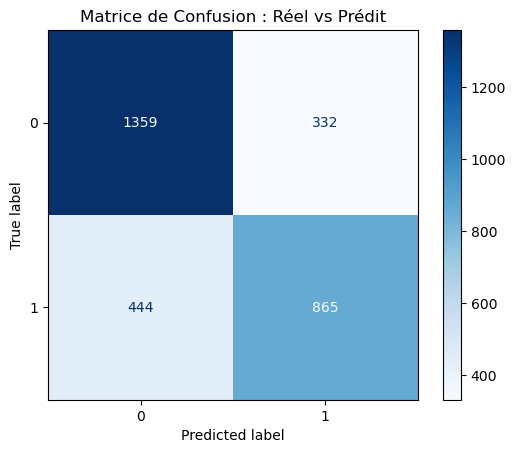

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lrn)

# L'afficher de manière élégante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_none.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion : Réel vs Prédit")
plt.show()

#### Avec librairie Statsmodels

Celle ci nous permet d'avoir des résultats plus détaillés. Nous pouvons analyser les p-valeurs et les poids des variables 

In [54]:
import statsmodels.api as sm

# Pour retrouver les noms dans le summary de statsmodels
X_train_df = pd.DataFrame(Xs_train, columns=health_features.columns)
X_train_df = sm.add_constant(X_train_df) # on ajoute un intercept pour que le modèle puisse apprendre une constante ( pas automatique dans la libraire)
regLog_stat = sm.Logit(Y_train.reset_index(drop=True), X_train_df).fit()
print(regLog_stat.summary())


Optimization terminated successfully.
         Current function value: 0.529313
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     Heart_Disease_Risk   No. Observations:                12000
Model:                          Logit   Df Residuals:                    11968
Method:                           MLE   Df Model:                           31
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2272
Time:                        10:00:37   Log-Likelihood:                -6351.8
converged:                       True   LL-Null:                       -8218.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.3162      0.022    -14.469      0.000      -0.359   

### Modèle linéaire avec pénalisation LASSO

$$\widehat{\beta}_{\text{Lasso}} = \text{argmin}_{\beta \in \mathbb{R}^{p+1}} \left( \sum_{i=1}^{n} (Y_i - \sum_{j=0}^{p} X_i^{(j)}\beta_j)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right) \text{Avec } \lambda \text{ un paramètre à calibrer }$$

Cette pénalité ajoute une pénalité au modèle s'il utilise trop de variables ou des coefficients trop grand. Il élimine les variables inutiles, et évite l'overfitting

#### Avec la librarie sklearn 

On utilise la fonction *LogisticRegressionCV*, celle ci trouve le meilleur lamda par cross-validation

note : vérifier que L1 c lasso

In [55]:
from sklearn.linear_model import LogisticRegressionCV

# on fait une validation à cs=5 plis et on teste 20 valeurs de C différentes (inverse de lambda, le paramètre de régularisation)
logReg_lasso = LogisticRegressionCV(penalty='l1',solver='saga', max_iter=10000, cv=5, Cs=20) #L1= lasso. Saga doit être utilisé pour la pénalité L1 car le solveur par défaut (liblinear) ne supporte pas la pénalité L1 
logReg_lasso.fit(Xs_train, Y_train)

print(f"Meilleur paramètre C trouvé : {logReg_lasso.C_[0]}")

Meilleur paramètre C trouvé : 11.288378916846883


In [56]:
# Prédiction
Y_pred_lrl = logReg_lasso.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lrl):.2%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lrl))

Précision du modèle : 74.20%
              precision    recall  f1-score   support

           0       0.75      0.80      0.78      1691
           1       0.72      0.66      0.69      1309

    accuracy                           0.74      3000
   macro avg       0.74      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000



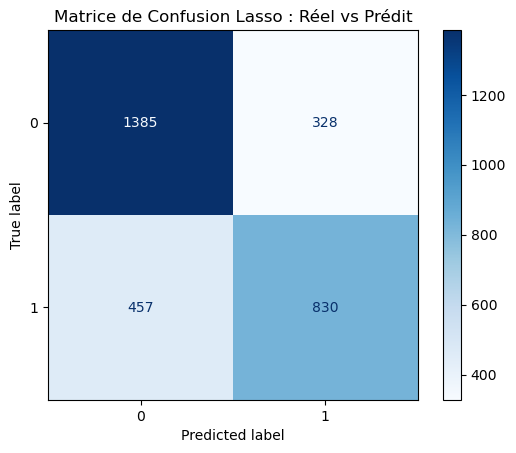

In [38]:
# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lrl)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_lasso.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()

Le Lasso a éliminé 0 variables sur 31.
Empty DataFrame
Columns: [Variable, Coefficient]
Index: []


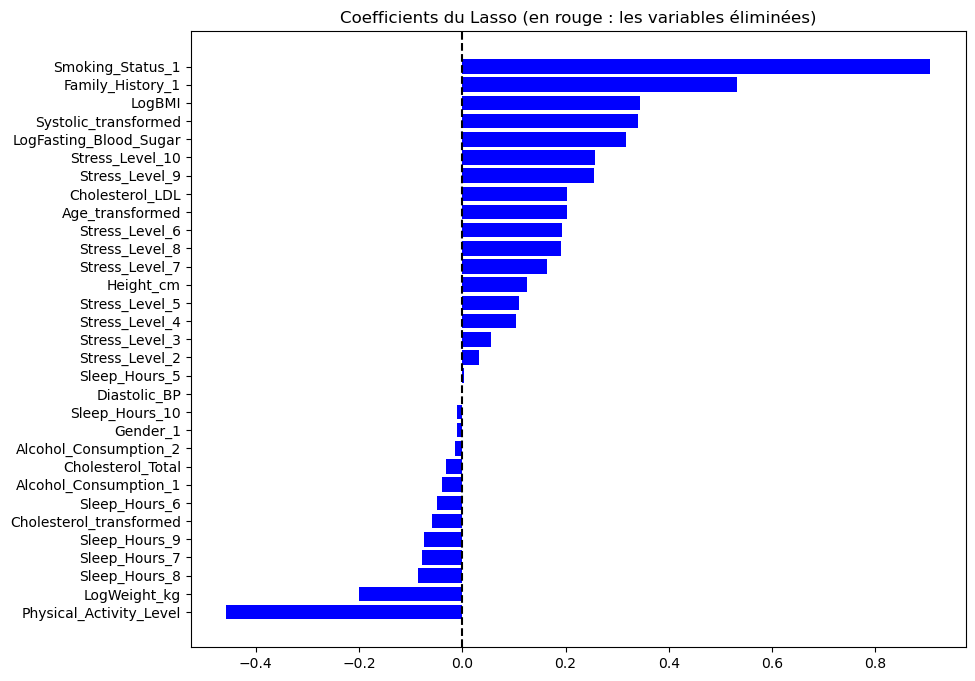

In [57]:
coeffs_df = pd.DataFrame({
    'Variable': health_features.columns, # nom des colonnes, pour l'analyse d'importance des variables
    'Coefficient': logReg_lasso.coef_[0] # .coef_[0] car pour une logistique binaire, c'est une liste de listes
})

variables_eliminees = coeffs_df[coeffs_df['Coefficient'] == 0]

print(f"Le Lasso a éliminé {len(variables_eliminees)} variables sur {len(health_features.columns)}.")
print(variables_eliminees)

coeffs_df = coeffs_df.sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
plt.barh(coeffs_df['Variable'], coeffs_df['Coefficient'], 
         color=['red' if c == 0 else 'blue' for c in coeffs_df['Coefficient']])
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Coefficients du Lasso (en rouge : les variables éliminées)")
plt.show()

Lorsqu'on ajoute une pénalisation, on "biaise" les coefficients pour les réduire. Les tests statistiques classiques ne marchent donc plus. Il n'est donc pas forcément pertinent d'utiliser Statsmodels

### Modèle linéaire avec pénalisation de Ridge 

$$\widehat{\beta} = \text{argmin}_{\widetilde{\beta} \in \mathbb{R}^{p+1}} \left( \| \mathbf{Y} - \widetilde{\mathbf{X}} \widetilde{\beta} \|^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \right) \text{Avec } \lambda \text{ à calibrer}$$

Contrairement à Ridge, cette pénalisation ne met pas les coefficients à 0, elle les réduit pour éviter l'overfitting. 

In [58]:
logReg_ridge = LogisticRegressionCV(penalty='l2', solver='lbfgs', max_iter=10000, cv=5, Cs=20)
logReg_ridge.fit(Xs_train, Y_train)
print(f"Meilleur paramètre C trouvé : {logReg_ridge.C_[0]}")

Meilleur paramètre C trouvé : 0.615848211066026


In [59]:

y_logReg_ridge = logReg_ridge.predict(Xs_test)
print(classification_report(Y_test, y_logReg_ridge))

              precision    recall  f1-score   support

           0       0.75      0.80      0.78      1691
           1       0.72      0.66      0.69      1309

    accuracy                           0.74      3000
   macro avg       0.74      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000



Le Ridge a éliminé 0 variables sur 31.
Empty DataFrame
Columns: [Variable, Coefficient]
Index: []


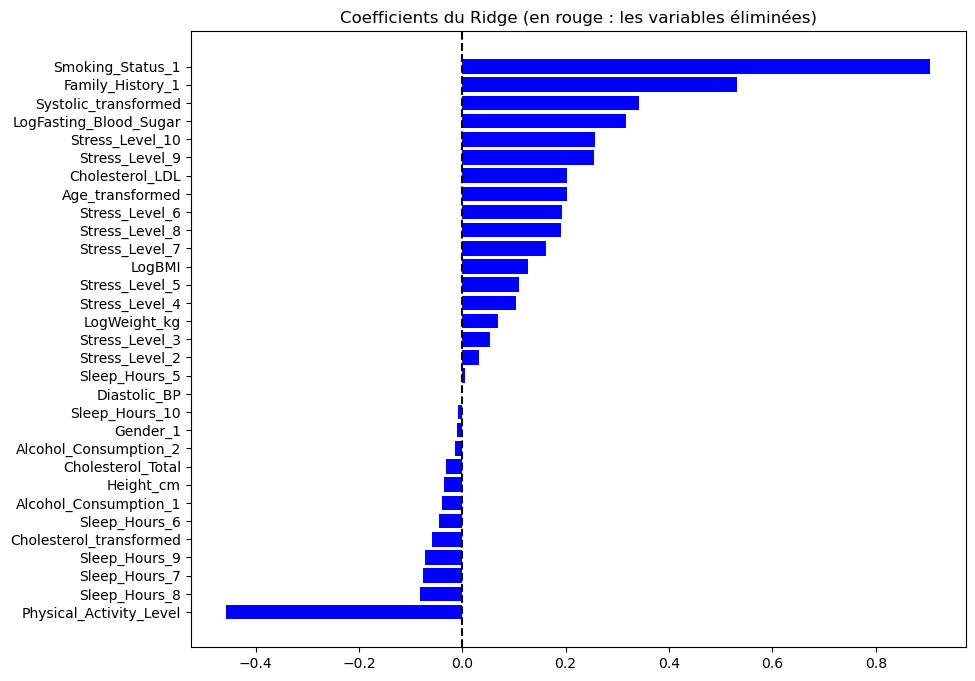

In [60]:
coeffs_df_ridge = pd.DataFrame({
    'Variable': health_features.columns, # nom des colonnes, pour l'analyse d'importance des variables
    'Coefficient': logReg_ridge.coef_[0] # .coef_[0] car pour une logistique binaire, c'est une liste de listes
})

variables_eliminees = coeffs_df_ridge[coeffs_df_ridge['Coefficient'] == 0]

print(f"Le Ridge a éliminé {len(variables_eliminees)} variables sur {len(health_features.columns)}.")
print(variables_eliminees)

coeffs_df_ridge = coeffs_df_ridge.sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
plt.barh(coeffs_df_ridge['Variable'], coeffs_df_ridge['Coefficient'], 
         color=['red' if c == 0 else 'blue' for c in coeffs_df_ridge['Coefficient']])
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Coefficients du Ridge (en rouge : les variables éliminées)")
plt.show()

### Conclusion 

| Métrique / Modèle | Sans pénalisation | Lasso (L1) | Ridge (L2) |
| :--- | :---: | :---: | :---: |
| **Paramètre C** | X | 11.28 | 0.66 |
| **Accuracy** | 0.74 | 0.74 | 0.74 |
| **Précision (Classe 0)** |0.75 |0.75 |0.75 |
| **Précision (Classe 1)** | 0.72| 0.72|0.72 |
| **Recall (Classe 0)** |0.8 | 0.8| 0.8|
| **Recall (Classe 1)** |0.66 |0.66 |0.66 |
| **Variables éliminées** | 0 | 0 | 0 |

On peut voir que les résultats sont identiques pour toutes les méthodes, c'està dire que malgré la pénalisation, le modèle de régréssion logistique classique a été choisi. Cependant, nous pouvons voir dans la sortie de *Statsmodels* que beaucoup de variables ont des p-valeurs très faible, ce qui semble indiquer que nous pouvons simplifier le modèle. Nous pourrions forcer un C très petit ou utiliser une méthode de séléction de variable. C'est ce que nous allons faire. 

note : est ce que j'aurai du faire directement avec GridSearch? 

### Modèles linéaire avec séléction de variable BIC 

Malheureusement, il n'y a pas de fonction toute prête (est ce que c'est too much de faire ça et il faut plutot jouer sur le paramètre C pour faire baisser le nombre de variables ?)

In [75]:
def forward_selection_bic(X, y): # avec X le dataFramme pandas qu'on a crée 
    best_features = []
    remaining_features = list(X.columns)
    print(remaining_features)
    current_bic = float('inf')
    
    while remaining_features: # tant qu'il reste des variables à tester
        candidates_scores = [] # liste pour stocker les scores BIC de chaque variable candidate
        for candidate in remaining_features: # on boucle sur les variables restantes pour tester leur ajout au modèle
            features_to_test = best_features + [candidate] # on teste le modèle avec les variables déjà retenues + la variable candidate
            X_const = sm.add_constant(X[features_to_test], has_constant='add') # on ajoute aussi l'intercept pour que le modèle puisse apprendre une constante ( pas automatique dans la libraire)
            
            try:
                model = sm.Logit(y.reset_index(drop=True), X_const).fit(disp=0) # on fait le modèle avec la variable candidate 
                candidates_scores.append((model.bic, candidate)) # on met le score BIC et la variable candidate dans la liste
            except:
                continue # si erreur, on ne fait
                
        if not candidates_scores: 
            break
            
        candidates_scores.sort() # Tri pour avoir le score BIC le plus petit au début
        best_new_bic, best_candidate = candidates_scores[0] # on prend la variable candidate qui a le meilleur score BIC (le plus petit)
        
        if best_new_bic < current_bic: # Si le meilleur BIC trouvé est plus petit que l'actuel, on valide la variable
            remaining_features.remove(best_candidate) # on retire la variable candidate des variables restantes à tester
            best_features.append(best_candidate) # on ajoute la variable candidate à la liste des variables retenues
            current_bic = best_new_bic # on met à jour le BIC actuel avec le meilleur BIC trouvé
            print(f"Ajouté : {best_candidate} -> Nouveau BIC : {current_bic:.2f}")
        else:
            # L'ajout d'une variable supplémentaire augmente le BIC (le modèle devient trop complexe), on s'arrête
            print("L'ajout de nouvelles variables n'améliore plus le BIC. Fin.")
            break
            
    print(f"\nVariables finales retenues par le BIC : {best_features}")
    return best_features


In [78]:
X_train_df = pd.DataFrame(Xs_train, columns=health_features.columns)
variables_optimales = forward_selection_bic(X_train_df, Y_train)
print("nombres de variables retenues : ", len(variables_optimales), " sur ", len(health_features.columns))

['Height_cm', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Physical_Activity_Level', 'LogWeight_kg', 'LogBMI', 'LogFasting_Blood_Sugar', 'Age_transformed', 'Systolic_transformed', 'Cholesterol_transformed', 'Gender_1', 'Smoking_Status_1', 'Family_History_1', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5', 'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9', 'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7', 'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10']
Ajouté : Smoking_Status_1 -> Nouveau BIC : 14932.22
Ajouté : Family_History_1 -> Nouveau BIC : 14397.48
Ajouté : Systolic_transformed -> Nouveau BIC : 13886.73
Ajouté : Physical_Activity_Level -> Nouveau BIC : 13488.05
Ajouté : LogFasting_Blood_Sugar -> Nouveau BIC : 13210.60
Ajouté : Cholesterol_LDL -> Nouveau BIC : 13084.35
Ajouté : LogBMI -> Nouveau BIC : 13035.63
Ajouté : Age_transformed -> Nouveau BIC : 1

On modifie notre DB pour séléctionner seulement ces variables, et on refait notre modèle. 

In [81]:
Xs_BIC=X_train_df[variables_optimales] # on garde uniquement les variables retenues par le BIC pour l'entraînement du modèle final
logReg_BIC = LogisticRegression(penalty=None, max_iter=10000)
logReg_BIC.fit(Xs_BIC, Y_train) 

LogisticRegression(max_iter=10000, penalty=None)

In [84]:
X_test_df = pd.DataFrame(Xs_test, columns=health_features.columns)
Xs_test_BIC = X_test_df[variables_optimales]
y_pred_BIC = logReg_BIC.predict(Xs_test_BIC)
print(classification_report(Y_test, y_pred_BIC))
print(f"Accuracy globale : {accuracy_score(Y_test, y_pred_BIC):.2f}")


              precision    recall  f1-score   support

           0       0.75      0.80      0.77      1691
           1       0.72      0.65      0.68      1309

    accuracy                           0.74      3000
   macro avg       0.73      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000

Accuracy globale : 0.74


toujours la même je vais devenir folle. Comment on a enlevé la moitié des variables et rien ne change ??? pk on les avait pas enlevé avant alors ???

### Conclusion 
fait par gemini à modifier 

1-Stabilité des performances : "L'application des pénalités L1, L2 et la sélection BIC montrent une convergence vers une accuracy de 0.74, ce qui suggère que le modèle a atteint sa capacité prédictive maximale pour une approche linéaire."

2-Interprétation du BIC : "Le modèle BIC est à privilégier car il offre la même performance (0.74) avec une structure plus simple, limitant ainsi les risques d'overfitting sur de nouvelles données."

3-Analyse des erreurs : Regarde si ce sont les mêmes individus qui sont mal classés par tous les modèles. Si oui, c'est que ces individus sont des "atypiques" que tes variables actuelles ne peuvent pas expliquer1

## SRM / SVM 
*linear support vector machine*

EVITER DE RELANCER CE QU4IL Y A EN DESSOUS? PREND 100 ANS 

In [91]:
from sklearn.svm import SVC # code prit du TP Ozonne 
from sklearn.model_selection import GridSearchCV

param=[{"C":[0.4,0.6,1,1.4]}]
svm= GridSearchCV(SVC(),param,cv=10,n_jobs=-1)
svmOpt=svm.fit(Xs_train, Y_train)
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt.best_score_,svmOpt.best_params_))

c:\Users\souve\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Meilleur score = 0.272333, Meilleur paramètre = {'C': 0.6}


In [92]:
# erreur de prévision sur le test
print(1-svmOpt.score(Xs_test,Y_test))
print("accuracy : ", svmOpt.score(Xs_test,Y_test))

0.2713333333333333
accuracy :  0.7286666666666667


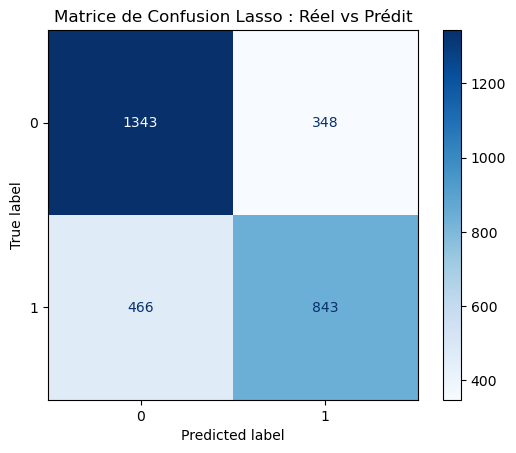

              precision    recall  f1-score   support

           0       0.74      0.79      0.77      1691
           1       0.71      0.64      0.67      1309

    accuracy                           0.73      3000
   macro avg       0.73      0.72      0.72      3000
weighted avg       0.73      0.73      0.73      3000



In [94]:
# prévision de l'échantillon test
y_chap = svmOpt.predict(Xs_test)
# matrice de confusion
cm = confusion_matrix(Y_test, y_chap)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svmOpt.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()

print (classification_report(Y_test, y_chap))

Bah c - bien ? Nul 

on peut faire avec differents noyaux ?

en 1000D, on ne peut pas faire les graphiques de séparation de petits points :()